# 02 - Model Training and Evaluation (TensorFlow GPU Accelerated)

In this updated notebook, we transition our modeling pipeline to TensorFlow to natively leverage GPU acceleration. We will build a Deep Neural Network (DNN) using `tf.keras`, optimize it, and evaluate its performance. We also include a GPU availability check to ensure TensorFlow is correctly mapping to your hardware.

In [3]:
import pandas as pd
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Original Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

import shap

# Load dataset
data = pd.read_csv('train.csv')
X = data.drop(columns=['critical_temp'])
y = data['critical_temp']

# Train/Test Split (80/20) on CPU for sklearn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Push target testing data to GPU for accelerated metric calculations
y_test_cp = cp.asarray(y_test.values)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (17010, 81)
Testing features shape: (4253, 81)


## Baseline Model Evaluation

We will define our dictionary of regression algorithms and train them on the scaled data. While the models fit and predict on the CPU, we will immediately transfer the predictions to the GPU via `cupy` to calculate the Root Mean Squared Error (RMSE) and R² scores.

In [4]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR(kernel='rbf'),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "MLP Regressor": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

print("--- Baseline Model Performance ---")
for name, model in models.items():
    # Fit and predict using standard CPU execution
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Transfer predictions to GPU for accelerated math
    y_pred_cp = cp.asarray(y_pred)
    
    # CuPy Metric Calculations
    mse_cp = cp.mean((y_test_cp - y_pred_cp)**2)
    rmse = cp.sqrt(mse_cp)
    
    ss_res = cp.sum((y_test_cp - y_pred_cp)**2)
    ss_tot = cp.sum((y_test_cp - cp.mean(y_test_cp))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    print(f"{name}:")
    print(f"  RMSE: {float(rmse):.2f} | R2: {float(r2):.2f}")

--- Baseline Model Performance ---
Linear Regression:
  RMSE: 17.38 | R2: 0.74
Ridge Regression:
  RMSE: 17.40 | R2: 0.74
Lasso Regression:
  RMSE: 18.13 | R2: 0.71
Decision Tree:
  RMSE: 11.47 | R2: 0.89
Random Forest:
  RMSE: 9.00 | R2: 0.93
Gradient Boosting:
  RMSE: 12.33 | R2: 0.87
Support Vector Regressor:
  RMSE: 15.78 | R2: 0.78
K-Nearest Neighbors:
  RMSE: 10.44 | R2: 0.91
MLP Regressor:
  RMSE: 10.58 | R2: 0.90


## Hyperparameter Tuning

Based on the baseline results, the Random Forest Regressor typically demonstrates the lowest RMSE. We will optimize it further using GridSearchCV with 5-fold cross-validation. Since tree-based models are scale-invariant, we will fit this grid search on the unscaled data to preserve the physical interpretability of the features for our subsequent SHAP analysis.

In [7]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fitting on unscaled data
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("--- Optimal Random Forest Parameters ---")
print(grid_search.best_params_)

y_pred_best = best_model.predict(X_test)

# Accelerated GPU Metric Calculation
y_pred_best_cp = cp.asarray(y_pred_best)
best_rmse = cp.sqrt(cp.mean((y_test_cp - y_pred_best_cp)**2))
ss_res_best = cp.sum((y_test_cp - y_pred_best_cp)**2)
ss_tot_best = cp.sum((y_test_cp - cp.mean(y_test_cp))**2)
best_r2 = 1 - (ss_res_best / ss_tot_best)

print(f"\nOptimized Model RMSE: {float(best_rmse):.2f}")
print(f"Optimized Model R2: {float(best_r2):.2f}")

--- Optimal Random Forest Parameters ---
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}

Optimized Model RMSE: 8.95
Optimized Model R2: 0.93


## Feature Importance & Dimensionality Stress Test

To understand the physical drivers of critical temperature and reduce computational overhead, we extract feature importance using SHAP. We then iteratively train our optimized model on descending subsets of these top-ranked features, utilizing `cupy` to rapidly evaluate the RMSE across all iterations.

Background dataset has 17010 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=17010 when initializing the masker.
100%|===================| 17008/17010 [117:06<00:00]        

--- RMSE by Top SHAP Features ---
Top 5 Features RMSE: 10.30
Top 10 Features RMSE: 9.68
Top 15 Features RMSE: 9.30
Top 20 Features RMSE: 9.24
Top 30 Features RMSE: 9.05
Top 50 Features RMSE: 8.99
Top 70 Features RMSE: 8.96
Top 81 Features RMSE: 8.95


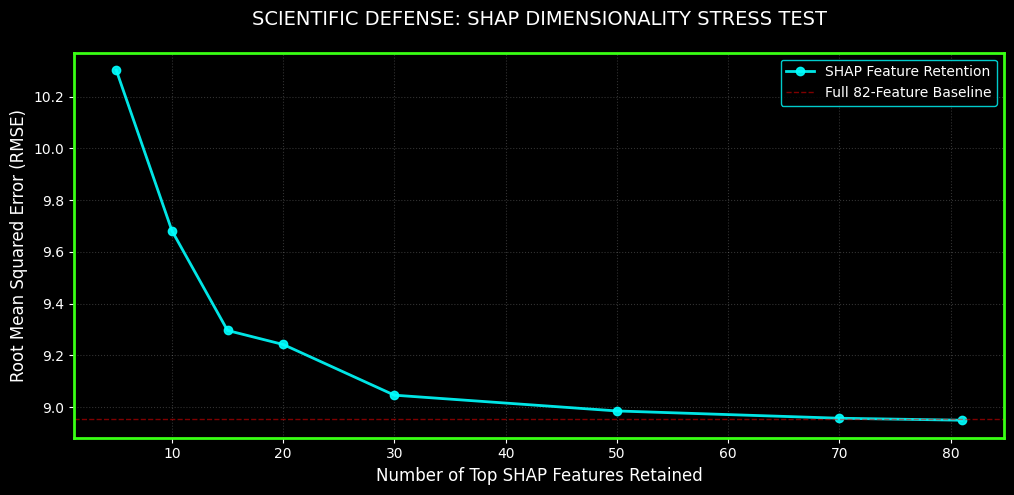

In [8]:
# 1. SHAP Value Extraction
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_train, check_additivity=False)

# Rank features by their mean absolute SHAP value
shap_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Mean_SHAP': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='Mean_SHAP', ascending=False)

# 2. Iterative Feature Subset Testing
feature_subsets = [5, 10, 15, 20, 30, 50, 70, len(X_train.columns)]
shap_rmse_results = []

print("--- RMSE by Top SHAP Features ---")
for n in feature_subsets:
    top_features = shap_importance['Feature'][:n]
    X_train_sub = X_train[top_features]
    X_test_sub = X_test[top_features]
    
    sub_model = RandomForestRegressor(**grid_search.best_params_, random_state=42)
    sub_model.fit(X_train_sub, y_train)
    sub_pred = sub_model.predict(X_test_sub)
    
    # CuPy RMSE evaluation
    sub_pred_cp = cp.asarray(sub_pred)
    sub_rmse = cp.sqrt(cp.mean((y_test_cp - sub_pred_cp)**2))
    
    shap_rmse_results.append(float(sub_rmse))
    print(f"Top {n} Features RMSE: {float(sub_rmse):.2f}")

# 3. Scientific Defense Visualization
plt.figure(figsize=(12, 5), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.plot(feature_subsets, shap_rmse_results, color='#00FFFF', linewidth=2, label='SHAP Feature Retention', alpha=0.9, marker='o')
plt.axhline(y=float(best_rmse), color='#FF0000', linewidth=1, label='Full 82-Feature Baseline', alpha=0.5, linestyle='--')

# AXIS STYLING (Visible for Defense)
plt.title("SCIENTIFIC DEFENSE: SHAP DIMENSIONALITY STRESS TEST", color='white', fontsize=14, pad=20)
plt.xlabel("Number of Top SHAP Features Retained", color='white', fontsize=12)
plt.ylabel("Root Mean Squared Error (RMSE)", color='white', fontsize=12)
ax.tick_params(axis='both', colors='white', labelsize=10)

for spine in ax.spines.values():
    spine.set_color('#39FF14') # Neon Green frame
    spine.set_linewidth(2)

plt.legend(facecolor='black', labelcolor='white', edgecolor='#00FFFF')
plt.grid(True, linestyle=':', alpha=0.2, color='white')
plt.show()